To create a baseline estimate of what would be useful for the model to achieve, for the elections 2005, 2010,2015, 2017 and 2019, I want to find the following: 

- The accuracy when predicting the constituency winner by assuming no change from previous election.
- The accuracy when predicting the consituency winner using a random forest model
- The accuracy among seats that chance when using this model.

I have selected a random forest model here because I am less interested about interpretability at this moment and purely want to see how we can expect a model to perform on classification. 

In [2]:
import pandas as pd

train_data = pd.read_csv('../TEST_TRAIN/train.csv')

need_cols = ['election', 'country/region','previous_majority_proportion',
       'previous_winner','Conservative', 'Labour', 'LD', 'incumbent','winner']

num_columns = ['previous_majority_proportion', 'Conservative', 'Labour', 'LD']
cat_columns = ['country/region', 'previous_winner', 'incumbent']

train_data1 = train_data[need_cols]

train_data1 = train_data1[train_data1['winner'] != 'oth'].copy()

In [3]:
### Output variable types for each column in train_data
pd.DataFrame({
    'column': train_data1.columns,
    'dtype': train_data1.dtypes.astype(str).values
})

,column,dtype
0,election,int64
1,country/region,str
2,previous_majority_proportion,float64
3,previous_winner,str
4,Conservative,float64
5,Labour,float64
6,LD,float64
7,incumbent,str
8,winner,str


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

election_years = [2005, 2010, 2015, 2017, 2019]
feature_columns = num_columns + cat_columns

results = []

for election_year in election_years:
    test = train_data1[train_data1['election'] == election_year]
    previous_elections = train_data1[train_data1['election'] < election_year]

    changed_seats = test['previous_winner'] != test['winner']

    previous_winner_predictions = test['previous_winner']
    previous_winner_accuracy = accuracy_score(test['winner'], previous_winner_predictions)
    
    X_train = pd.get_dummies(previous_elections[feature_columns])
    y_train = previous_elections['winner']
    X_test = pd.get_dummies(test[feature_columns]).reindex(columns=X_train.columns, fill_value=0)

    random_forest = RandomForestClassifier()
    random_forest.fit(X_train, y_train)
    random_forest_predictions = random_forest.predict(X_test)

    random_forest_accuracy = accuracy_score(test['winner'], random_forest_predictions)
    random_forest_changed_accuracy = accuracy_score(
        test.loc[changed_seats, 'winner'],
        random_forest_predictions[changed_seats]
    )

    results.append({
        'election': election_year,
        'previous_winner_accuracy': previous_winner_accuracy,
        'random_forest_accuracy': random_forest_accuracy,
        'random_forest_changed_seats_accuracy': random_forest_changed_accuracy,
        'changed_seats': changed_seats.sum()
    })

results = pd.DataFrame(results)
accuracy_columns = [
    'previous_winner_accuracy',
    'random_forest_accuracy',
    'random_forest_changed_seats_accuracy'
]

results[accuracy_columns] = results[accuracy_columns].round(3)
results

,election,previous_winner_accuracy,random_forest_accuracy,random_forest_changed_seats_accuracy,changed_seats
0,2005,0.912,0.905,0.036,55
1,2010,0.825,0.832,0.545,110
2,2015,0.830,0.780,0.047,107
3,2017,0.894,0.890,0.045,67
4,2019,0.881,0.881,0.133,75


Here it is not interesting how the random forest for 2010 has such strong accuracy for the changed seats. It is likely because at this point there had only been two unique entries for the polling figures. As seen in the polling line chart in 01_baseline models.IPYNB, the polling for conservatives went up as well as their seats and the polling for labour went down as well as their seats. The model therefore presumably leanrs this. Hence, the 2019 prediciton is probably most illustrative of a fair accuracy and we can see that it barely differs from predicting the same as last election.

Since we cannot imporve the data by adding more elections going backwards, I am attempting to imporve the model by feature engineering. Specifically, by including introducing a new projected share for each party in each constituency. I created this in 4_projected_polling.sql. The feature is defined as the following:

$$
\begin{aligned}
\text{party X projected share} ={}& \text{party X share at last election} \\
&+ \text{party X national polling} \\
&- \text{party X share of constituencies at last election}
\end{aligned}
$$

In [5]:
need_cols2 = need_cols = ['election','winner', 'country/region','previous_majority_proportion',
       'previous_winner','Conservative', 'Labour', 'LD', 'incumbent',
       'previous_con_share', 'previous_lib_share', 'previous_lab_share',
       'previous_natSW_share', 'projected_con_share', 'projected_lib_share', 'projected_lab_share'
]

train_data2 = train_data[need_cols2]
train_data2 = train_data2[train_data2['winner'] != 'oth'].copy()

In [6]:

election_years = [2005, 2010, 2015, 2017, 2019]
feature_columns2 = need_cols2[2:]  # Exclude 'election', and 'winner'

results = []

for election_year in election_years:
    test = train_data2[train_data2['election'] == election_year]
    previous_elections = train_data2[train_data2['election'] < election_year]

    changed_seats = test['previous_winner'] != test['winner']

    previous_winner_predictions = test['previous_winner']
    previous_winner_accuracy = accuracy_score(test['winner'], previous_winner_predictions)
    
    X_train = pd.get_dummies(previous_elections[feature_columns2])
    y_train = previous_elections['winner']
    X_test = pd.get_dummies(test[feature_columns]).reindex(columns=X_train.columns, fill_value=0)

    random_forest = RandomForestClassifier()
    random_forest.fit(X_train, y_train)
    random_forest_predictions = random_forest.predict(X_test)

    random_forest_accuracy = accuracy_score(test['winner'], random_forest_predictions)
    random_forest_changed_accuracy = accuracy_score(
        test.loc[changed_seats, 'winner'],
        random_forest_predictions[changed_seats]
    )

    results.append({
        'election': election_year,
        'previous_winner_accuracy': previous_winner_accuracy,
        'random_forest_accuracy': random_forest_accuracy,
        'random_forest_changed_seats_accuracy': random_forest_changed_accuracy,
        'changed_seats': changed_seats.sum()
    })

results = pd.DataFrame(results)
accuracy_columns = [
    'previous_winner_accuracy',
    'random_forest_accuracy',
    'random_forest_changed_seats_accuracy'
]

results[accuracy_columns] = results[accuracy_columns].round(3)
results

,election,previous_winner_accuracy,random_forest_accuracy,random_forest_changed_seats_accuracy,changed_seats
0,2005,0.912,0.912,0.000,55
1,2010,0.825,0.819,0.000,110
2,2015,0.830,0.830,0.000,107
3,2017,0.894,0.890,0.015,67
4,2019,0.881,0.870,0.040,75


With the training data we have, predicting the seat's winner purely off previous holder gives a strong accuracy. However, we know this greatly limits the ability of the model to generalise to future elections. This information coupled with the fact that our models trained so far have a very poor accuracy on seats that change seat, suggests we should aim to increase accuracy in that area.

Boxplots showing how the selected predictors vary by constituency winner across the whole `train_data2` dataset.

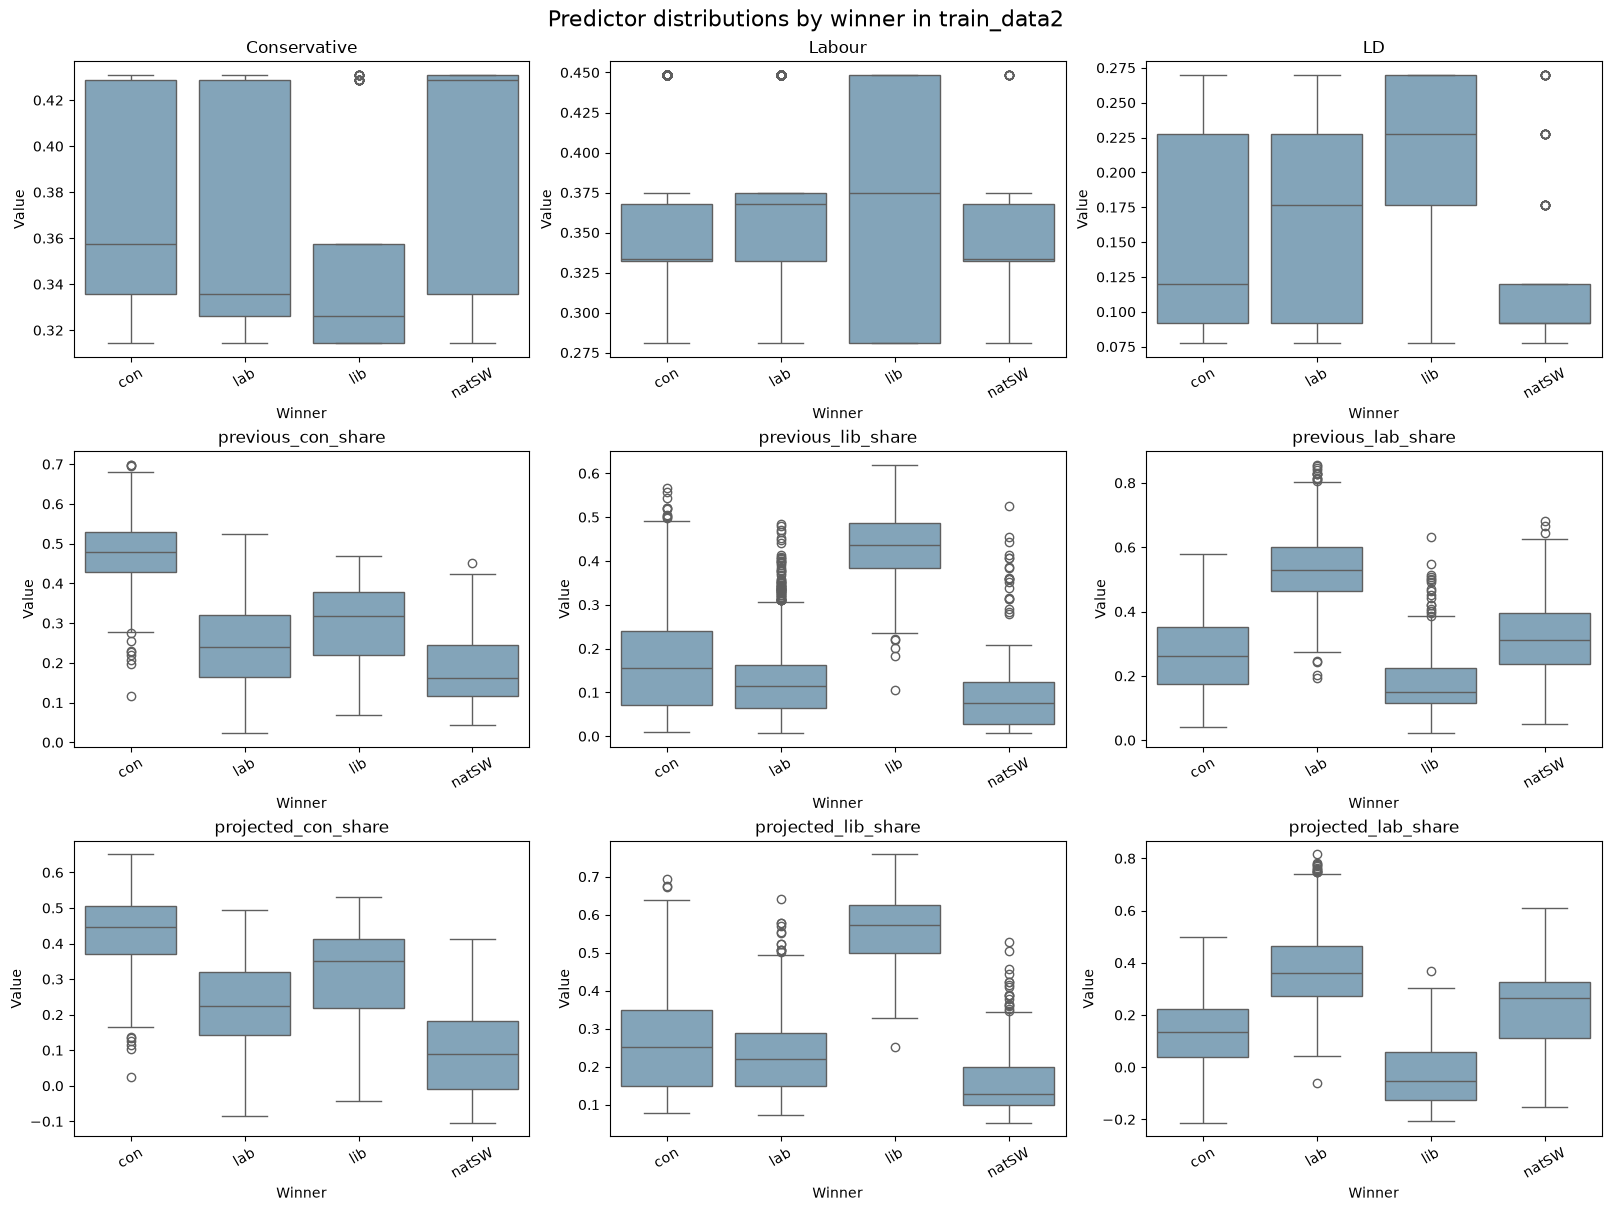

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

boxplot_predictors = [
    'Conservative', 'Labour', 'LD',
    'previous_con_share', 'previous_lib_share', 'previous_lab_share',
    'projected_con_share', 'projected_lib_share', 'projected_lab_share'
]

boxplot_data = train_data2[['winner', *boxplot_predictors]].melt(
    id_vars='winner',
    var_name='predictor',
    value_name='value'
).dropna()

winner_order = sorted(boxplot_data['winner'].unique())

fig, axes = plt.subplots(3, 3, figsize=(16, 12), constrained_layout=True)

for ax, predictor in zip(axes.flat, boxplot_predictors):
    sns.boxplot(
        data=boxplot_data[boxplot_data['predictor'] == predictor],
        x='winner',
        y='value',
        order=winner_order,
        ax=ax,
        color='#7aa6c2'
    )
    ax.set_title(predictor)
    ax.set_xlabel('Winner')
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Predictor distributions by winner in train_data2', fontsize=16)
plt.show()